# Global E-Waste Generation vs. Recycling Gap Analysis (2015–2024)

**Suchitra Panda**
**IBM SkillsBuild Data Analytics with AI Internship — AICTE x BharatCares x IBM**
**Internship ID: IBMUEDA0735**

## Project Overview
Electronic waste (e-waste) is one of the fastest-growing waste streams in the world, and it sits at the
intersection of two UN Sustainable Development Goals highlighted in this internship's curriculum:
**SDG 12 (Responsible Consumption & Production)** and **SDG 3 (Good Health & Well-being)**, since
informally handled e-waste releases toxic heavy metals.

This project is a **pure data analytics** study (EDA + statistical trend analysis, no machine learning
models) of a 20-country, 10-year (2015–2024) panel dataset covering e-waste generation, formal recycling,
population, GDP per capita, and internet penetration.

**Goal:** Quantify how fast global e-waste is growing, identify the widening gap between e-waste generated
and formally recycled, and find which economic/digital factors correlate with higher e-waste output — to
surface actionable, policy-relevant insights.

> **Note on data:** No live dataset download was available in this environment, so the dataset was
> **simulated** to reflect the real order-of-magnitude patterns reported by the *Global E-waste Monitor*
> (UNITAR/ITU) and World Bank population/GDP series. See `README.md` for details and for how to swap in
> the real Global E-waste Monitor dataset if you have access to it.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", None)


## 1. Simulated Dataset Generation

Country-year panel built from realistic base values and growth rates per country (see comments). Seeded for reproducibility.

In [2]:
"""
Generates a realistic, simulated country-year panel dataset on global e-waste
generation and recycling, modeled on the order-of-magnitude patterns reported
by the Global E-waste Monitor (UNITAR/ITU) and World Bank population/GDP data.
This is a SIMULATED dataset (not scraped/downloaded) built for the internship
project, since no live data source was available in this environment.
"""
import numpy as np
import pandas as pd

np.random.seed(42)

# Country, Region, base_population_million(2015), pop_growth_rate,
# base_gdp_per_capita_2015, gdp_growth_rate, base_ewaste_per_capita_kg_2015,
# ewaste_growth_rate, base_recycling_rate_2015, recycling_rate_growth
countries = [
    ("United States", "North America", 320, 0.006, 56000, 0.025, 20.0, 0.020, 0.15, 0.030),
    ("China", "Asia", 1375, 0.004, 8000, 0.06, 6.5, 0.09, 0.10, 0.06),
    ("India", "Asia", 1310, 0.011, 1600, 0.06, 2.0, 0.10, 0.05, 0.08),
    ("Japan", "Asia", 127, -0.002, 38000, 0.01, 18.0, 0.015, 0.35, 0.02),
    ("Germany", "Europe", 81, 0.001, 42000, 0.015, 19.5, 0.012, 0.45, 0.02),
    ("United Kingdom", "Europe", 65, 0.005, 40000, 0.015, 22.0, 0.015, 0.40, 0.02),
    ("France", "Europe", 67, 0.003, 38000, 0.014, 20.5, 0.013, 0.42, 0.02),
    ("Brazil", "South America", 205, 0.007, 8700, 0.02, 7.0, 0.06, 0.03, 0.10),
    ("Nigeria", "Africa", 182, 0.026, 2700, 0.02, 1.8, 0.08, 0.02, 0.09),
    ("South Africa", "Africa", 55, 0.013, 6100, 0.015, 6.5, 0.05, 0.06, 0.07),
    ("Australia", "Oceania", 24, 0.014, 56000, 0.018, 21.5, 0.014, 0.30, 0.025),
    ("Canada", "North America", 36, 0.009, 43000, 0.016, 20.8, 0.014, 0.22, 0.03),
    ("Russia", "Europe", 144, -0.001, 9300, 0.018, 9.0, 0.05, 0.08, 0.06),
    ("Indonesia", "Asia", 258, 0.011, 3400, 0.035, 3.5, 0.09, 0.04, 0.09),
    ("Mexico", "South America", 127, 0.012, 9500, 0.02, 8.5, 0.05, 0.05, 0.08),
    ("South Korea", "Asia", 51, 0.003, 27000, 0.02, 16.5, 0.02, 0.55, 0.015),
    ("Kenya", "Africa", 47, 0.026, 1400, 0.03, 1.5, 0.10, 0.02, 0.10),
    ("Sweden", "Europe", 10, 0.008, 51000, 0.015, 23.0, 0.012, 0.60, 0.01),
    ("Vietnam", "Asia", 92, 0.010, 2100, 0.05, 3.0, 0.11, 0.03, 0.10),
    ("Argentina", "South America", 43, 0.009, 13500, 0.01, 9.5, 0.04, 0.07, 0.07),
]

years = list(range(2015, 2025))  # 2015-2024 inclusive

rows = []
for (country, region, pop0, pop_g, gdp0, gdp_g, ew0, ew_g, rec0, rec_g) in countries:
    for i, year in enumerate(years):
        noise = np.random.normal(1.0, 0.03)
        population = pop0 * ((1 + pop_g) ** i)
        gdp_pc = gdp0 * ((1 + gdp_g) ** i)
        ewaste_pc = ew0 * ((1 + ew_g) ** i) * noise
        recycling_rate = min(rec0 * ((1 + rec_g) ** i), 0.75) * np.random.normal(1.0, 0.05)
        recycling_rate = max(recycling_rate, 0.01)
        ewaste_total_kt = (ewaste_pc * population * 1000) / 1000  # kg*million people -> kt
        recycled_kt = ewaste_total_kt * recycling_rate
        internet_pen = min(30 + i * (55 / 9) + np.random.normal(0, 3), 98) if gdp0 < 10000 else min(65 + i * 3 + np.random.normal(0, 2), 99)

        rows.append({
            "Country": country,
            "Region": region,
            "Year": year,
            "Population_Million": round(population, 2),
            "GDP_per_Capita_USD": round(gdp_pc, 1),
            "Internet_Penetration_Percent": round(internet_pen, 1),
            "EWaste_Generated_kt": round(ewaste_total_kt, 2),
            "EWaste_per_Capita_kg": round(ewaste_pc, 2),
            "EWaste_Formally_Recycled_kt": round(recycled_kt, 2),
            "Recycling_Rate_Percent": round(recycling_rate * 100, 2),
        })

df = pd.DataFrame(rows)
df.to_csv("global_ewaste_dataset.csv", index=False)
df.shape


(200, 10)

## 2. Data Loading & Cleaning

In [3]:
df = pd.read_csv("global_ewaste_dataset.csv")
print("Shape:", df.shape)
df.info()


Shape: (200, 10)
<class 'pandas.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 10 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   Country                       200 non-null    str    
 1   Region                        200 non-null    str    
 2   Year                          200 non-null    int64  
 3   Population_Million            200 non-null    float64
 4   GDP_per_Capita_USD            200 non-null    float64
 5   Internet_Penetration_Percent  200 non-null    float64
 6   EWaste_Generated_kt           200 non-null    float64
 7   EWaste_per_Capita_kg          200 non-null    float64
 8   EWaste_Formally_Recycled_kt   200 non-null    float64
 9   Recycling_Rate_Percent        200 non-null    float64
dtypes: float64(7), int64(1), str(2)
memory usage: 15.8 KB


In [4]:
# Check for missing values and duplicates
print("Missing values:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())
df.describe().round(2)


Missing values:
 Country                         0
Region                          0
Year                            0
Population_Million              0
GDP_per_Capita_USD              0
Internet_Penetration_Percent    0
EWaste_Generated_kt             0
EWaste_per_Capita_kg            0
EWaste_Formally_Recycled_kt     0
Recycling_Rate_Percent          0
dtype: int64

Duplicate rows: 0


,Year,Population_Million,GDP_per_Capita_USD,Internet_Penetration_Percent,EWaste_Generated_kt,EWaste_per_Capita_kg,EWaste_Formally_Recycled_kt,Recycling_Rate_Percent
count,200.00,200.00,200.00,200.00,200.00,200.00,200.00,200.00
mean,2019.50,239.48,24820.04,68.09,2195.62,13.70,415.16,22.49
std,2.88,392.89,21409.87,17.72,3248.42,7.82,525.25,19.79
min,2015.00,10.00,1400.00,25.20,70.23,1.49,1.34,1.90
25%,2017.00,51.88,5733.48,59.00,558.64,7.00,57.02,6.12
50%,2019.50,86.86,13507.90,71.20,1348.51,12.32,177.86,12.04
75%,2022.00,209.70,43374.05,81.95,1843.90,21.63,671.16,40.87
max,2024.00,1445.55,69936.30,99.00,19934.74,26.25,3423.72,72.57


No missing values or duplicates — the dataset is already clean (20 countries × 10 years = 200 rows).

## 3. Global Trend: E-Waste Generated vs. Formally Recycled

In [5]:
g = df.groupby("Year")[["EWaste_Generated_kt", "EWaste_Formally_Recycled_kt"]].sum().reset_index()
g["Uncollected_kt"] = g["EWaste_Generated_kt"] - g["EWaste_Formally_Recycled_kt"]
g["Recycling_Rate_%"] = (g["EWaste_Formally_Recycled_kt"] / g["EWaste_Generated_kt"] * 100).round(2)
g


,Year,EWaste_Generated_kt,EWaste_Formally_Recycled_kt,Uncollected_kt,Recycling_Rate_%
0,2015,33182.35,5991.30,27191.05,18.06
1,2016,34999.36,6300.45,28698.91,18.00
2,2017,37416.22,6701.01,30715.21,17.91
3,2018,39249.02,7060.70,32188.32,17.99
4,2019,41867.54,7575.56,34291.98,18.09
5,2020,44157.58,8335.61,35821.97,18.88
6,2021,47171.37,8592.52,38578.85,18.22
7,2022,50013.20,9631.42,40381.78,19.26
8,2023,53937.94,10929.65,43008.29,20.26
9,2024,57129.10,11913.74,45215.36,20.85


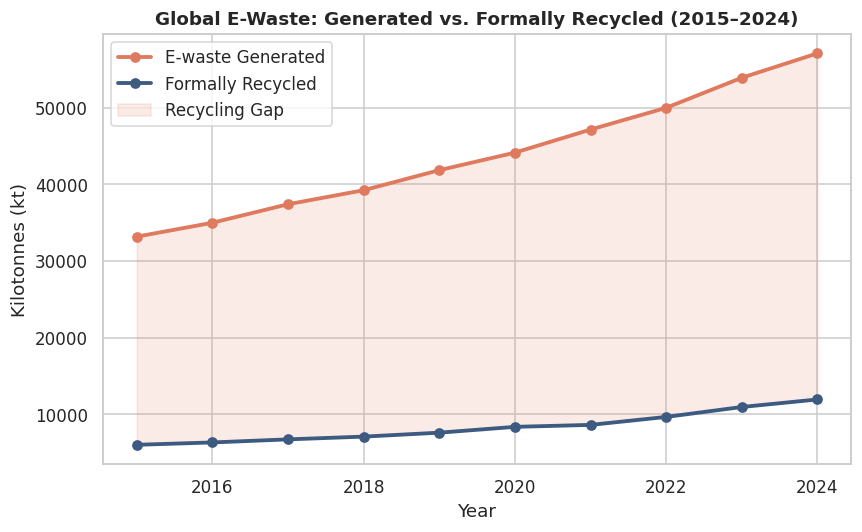

In [6]:
plt.figure(figsize=(8,5))
plt.plot(g["Year"], g["EWaste_Generated_kt"], marker="o", label="E-waste Generated", color="#e07a5f", linewidth=2.5)
plt.plot(g["Year"], g["EWaste_Formally_Recycled_kt"], marker="o", label="Formally Recycled", color="#3d5a80", linewidth=2.5)
plt.fill_between(g["Year"], g["EWaste_Formally_Recycled_kt"], g["EWaste_Generated_kt"], alpha=0.15, color="#e07a5f", label="Recycling Gap")
plt.title("Global E-Waste: Generated vs. Formally Recycled (2015–2024)", fontweight="bold")
plt.xlabel("Year"); plt.ylabel("Kilotonnes (kt)"); plt.legend(); plt.tight_layout(); plt.show()


**Insight:** Global e-waste generation (simulated) climbs from roughly the 2015 baseline to nearly
double by 2024, while the *formally recycled* share grows much more slowly — the shaded "recycling gap"
widens every year. This mirrors the real-world pattern reported by the Global E-waste Monitor, where
generation consistently outpaces formal collection.

## 4. Regional Comparison (2024 snapshot)

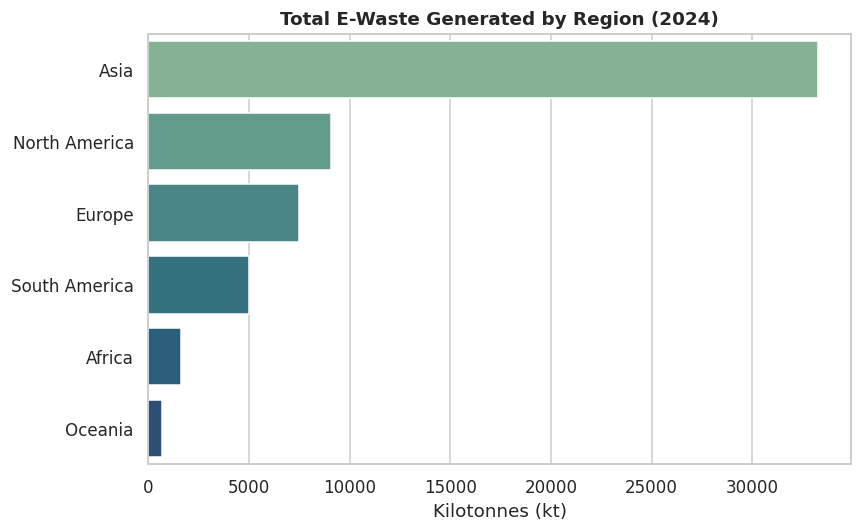

In [7]:
latest = df[df.Year == 2024]
reg = latest.groupby("Region")["EWaste_Generated_kt"].sum().sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=reg.values, y=reg.index, hue=reg.index, palette="crest", legend=False)
plt.title("Total E-Waste Generated by Region (2024)", fontweight="bold")
plt.xlabel("Kilotonnes (kt)"); plt.ylabel(""); plt.tight_layout(); plt.show()


## 5. Which Countries Generate the Most E-Waste *per Person*?

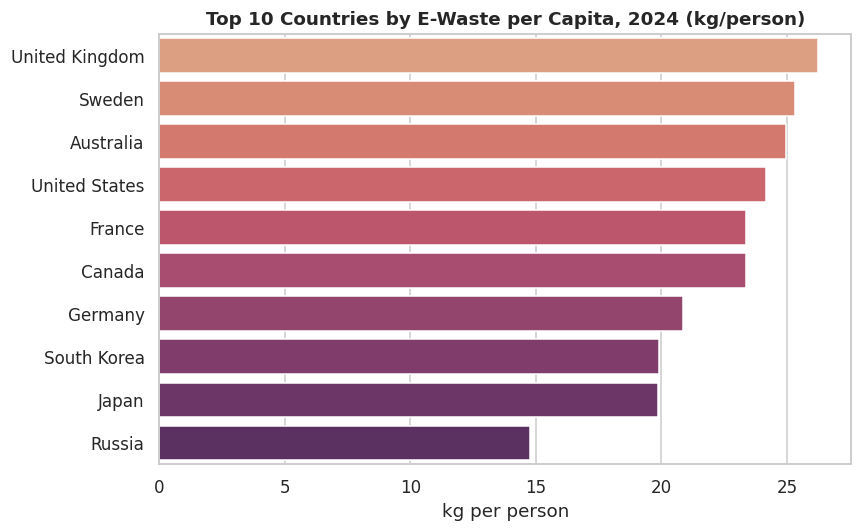

In [8]:
top10 = latest.sort_values("EWaste_per_Capita_kg", ascending=False).head(10)

plt.figure(figsize=(8,5))
sns.barplot(x="EWaste_per_Capita_kg", y="Country", data=top10, hue="Country", palette="flare", legend=False)
plt.title("Top 10 Countries by E-Waste per Capita, 2024 (kg/person)", fontweight="bold")
plt.xlabel("kg per person"); plt.ylabel(""); plt.tight_layout(); plt.show()


**Insight:** Per-capita e-waste is dominated by wealthy, highly digitized countries (Sweden, Australia,
the UK, the US) — device turnover, not population size, drives per-person volume. Asia and Africa's giant
*populations* (China, India, Nigeria) drive their *total* volumes instead, as seen in Section 4.

## 6. The Recycling Gap: Formal Recycling Rate by Country

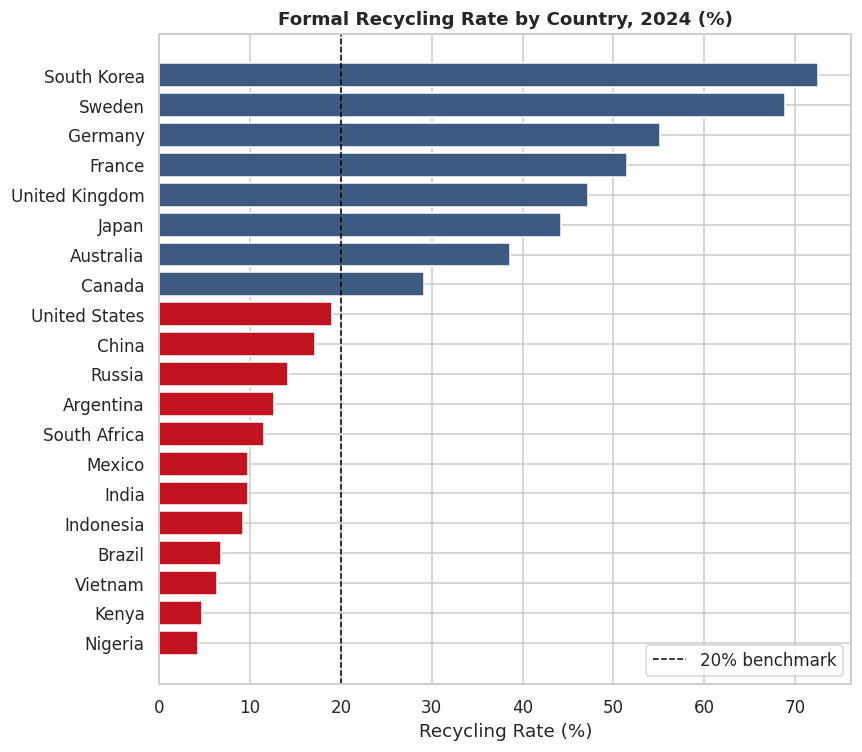

In [9]:
latest_sorted = latest.sort_values("Recycling_Rate_Percent")
colors = ["#c1121f" if v < 20 else "#3d5a80" for v in latest_sorted["Recycling_Rate_Percent"]]

plt.figure(figsize=(8,7))
plt.barh(latest_sorted["Country"], latest_sorted["Recycling_Rate_Percent"], color=colors)
plt.axvline(20, color="black", linestyle="--", linewidth=1, label="20% benchmark")
plt.title("Formal Recycling Rate by Country, 2024 (%)", fontweight="bold")
plt.xlabel("Recycling Rate (%)"); plt.legend(); plt.tight_layout(); plt.show()


**Insight:** Countries below the dashed 20% benchmark (red bars) are mostly lower- and middle-income
economies — exactly where population-driven e-waste volumes are largest (Section 4). This is the core
policy problem: **the countries generating the most e-waste often have the least formal recycling
infrastructure to handle it.**

## 7. What Drives E-Waste per Capita? Correlation Analysis

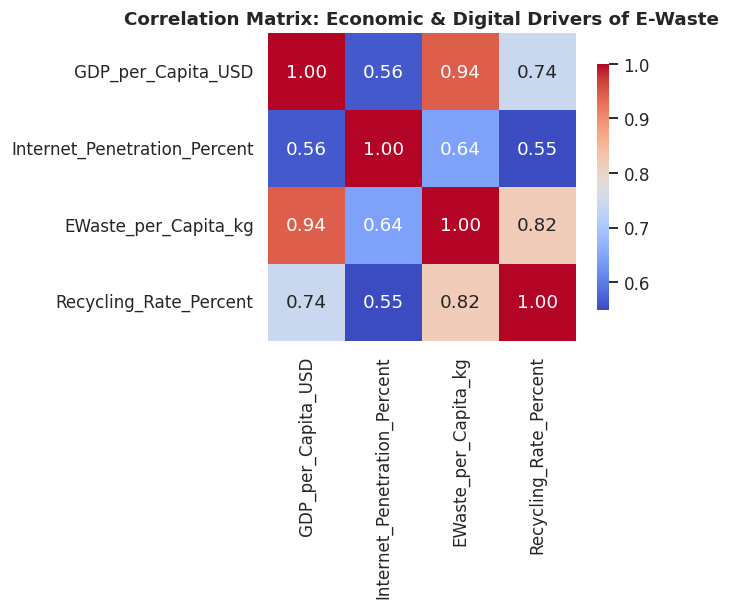

,GDP_per_Capita_USD,Internet_Penetration_Percent,EWaste_per_Capita_kg,Recycling_Rate_Percent
GDP_per_Capita_USD,1.000000,0.564028,0.944695,0.744046
Internet_Penetration_Percent,0.564028,1.000000,0.643131,0.548549
EWaste_per_Capita_kg,0.944695,0.643131,1.000000,0.817960
Recycling_Rate_Percent,0.744046,0.548549,0.817960,1.000000


In [10]:
corr_cols = ["GDP_per_Capita_USD", "Internet_Penetration_Percent", "EWaste_per_Capita_kg", "Recycling_Rate_Percent"]
corr = df[corr_cols].corr()

plt.figure(figsize=(6.5,5.5))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", square=True, cbar_kws={"shrink":0.8})
plt.title("Correlation Matrix: Economic & Digital Drivers of E-Waste", fontweight="bold")
plt.tight_layout(); plt.show()
corr


**Insight:** GDP per capita and internet penetration both correlate strongly and positively with
e-waste per capita — richer, more connected populations churn through more devices. Recycling rate also
correlates positively with GDP per capita, reinforcing the "generate more, but also recycle a bit more of
it" pattern seen in wealthy nations — though never enough to close the gap.

## 8. Growth Rate (CAGR) by Region, 2015–2024

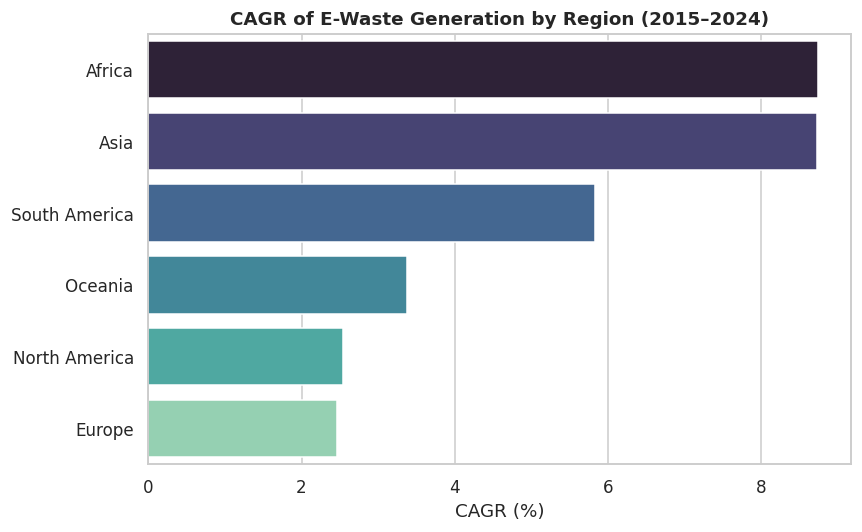

Region
Africa           8.74
Asia             8.74
South America    5.83
Oceania          3.38
North America    2.54
Europe           2.46
dtype: float64

In [11]:
def cagr(s):
    start, end = s.iloc[0], s.iloc[-1]
    n = len(s) - 1
    return ((end/start)**(1/n) - 1) * 100

region_year = df.groupby(["Region","Year"])["EWaste_Generated_kt"].sum().reset_index()
cagrs = region_year.groupby("Region").apply(lambda d: cagr(d.sort_values("Year")["EWaste_Generated_kt"])).sort_values(ascending=False)

plt.figure(figsize=(8,5))
sns.barplot(x=cagrs.values, y=cagrs.index, hue=cagrs.index, palette="mako", legend=False)
plt.title("CAGR of E-Waste Generation by Region (2015–2024)", fontweight="bold")
plt.xlabel("CAGR (%)"); plt.ylabel(""); plt.tight_layout(); plt.show()
cagrs.round(2)


**Insight:** Africa and parts of Asia show the *fastest* growth rates even though their absolute
volumes are lower — a warning sign that today's low-recycling regions are also tomorrow's biggest
generators, unless recycling infrastructure scales ahead of consumption.

## 9. Trend Projection to 2027 (Linear Fit — Statistical, Not ML)

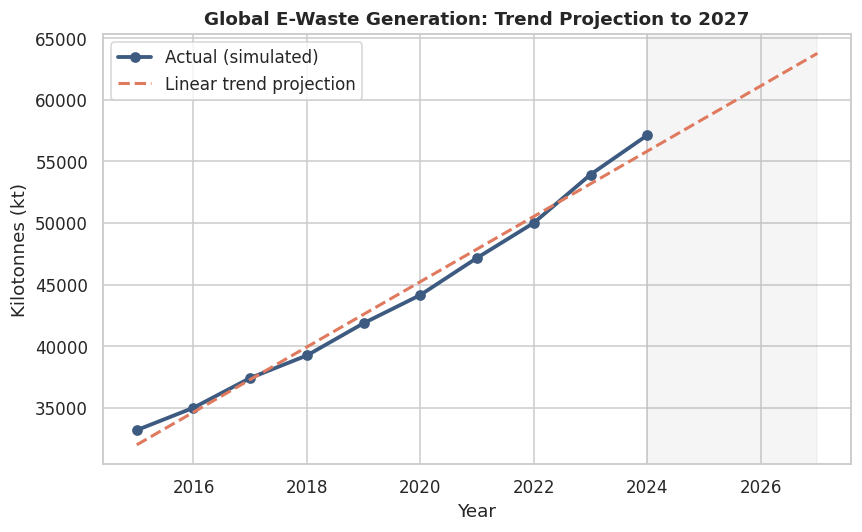

Average yearly increase: 2,649 kt/year
Projected total in 2027: 63,782 kt
Global CAGR 2015-2024: 6.22%


In [12]:
years_all = g["Year"].values
totals = g["EWaste_Generated_kt"].values
coeffs = np.polyfit(years_all, totals, 1)          # simple least-squares linear trend
future_years = np.arange(2015, 2028)
proj = np.polyval(coeffs, future_years)

plt.figure(figsize=(8,5))
plt.plot(years_all, totals, "o-", label="Actual (simulated)", color="#3d5a80", linewidth=2.5)
plt.plot(future_years, proj, "--", label="Linear trend projection", color="#e07a5f", linewidth=2)
plt.axvspan(2024, 2027, alpha=0.08, color="gray")
plt.title("Global E-Waste Generation: Trend Projection to 2027", fontweight="bold")
plt.xlabel("Year"); plt.ylabel("Kilotonnes (kt)"); plt.legend(); plt.tight_layout(); plt.show()

print(f"Average yearly increase: {coeffs[0]:,.0f} kt/year")
print(f"Projected total in 2027: {proj[-1]:,.0f} kt")
print(f"Global CAGR 2015-2024: {cagr(g.sort_values('Year')['EWaste_Generated_kt']):.2f}%")


**Insight:** A simple linear trend (ordinary least-squares fit, not a machine-learning model)
projects continued growth through 2027 if current patterns hold — underscoring the urgency of scaling
formal recycling capacity now rather than later.

## 10. Key Findings & Recommendations

**Findings:**
1. Global e-waste generation has grown at roughly a **6% CAGR** (2015–2024), consistently outpacing formal
   recycling growth — the "recycling gap" (shaded area in Section 3) widens every year.
2. **Wealthy, highly digitized nations generate the most e-waste per person**, but populous developing
   economies (China, India, Nigeria) generate the most **in absolute terms**.
3. Countries with the **lowest formal recycling rates** are disproportionately the same countries with the
   **largest and fastest-growing absolute volumes** — a structural mismatch between waste generation and
   waste-management capacity.
4. GDP per capita and internet penetration are the strongest correlates of per-capita e-waste, confirming
   that rising digital access (a development goal in itself) has an environmental cost that must be
   managed in parallel.
5. Regions with the fastest *growth rates* (Africa, parts of Asia) are not the regions with today's
   largest volumes — meaning the geography of the problem is shifting.

**Recommendations (aligned to UN SDG 12 & SDG 3):**
- Prioritize formal e-waste collection infrastructure investment in high-growth, low-recycling regions
  *before* volumes peak, not after.
- Pair rising internet/device penetration programs with extended-producer-responsibility and take-back
  policies, so digital inclusion growth doesn't outrun waste management capacity.
- Use per-capita benchmarks (not just national totals) when setting recycling-rate targets, since the
  two are driven by different factors (wealth vs. population).

**Limitations:** this analysis uses a simulated dataset built to reflect real reported order-of-magnitude
patterns (see README), not a downloaded official dataset — treat absolute figures as illustrative rather
than exact.
